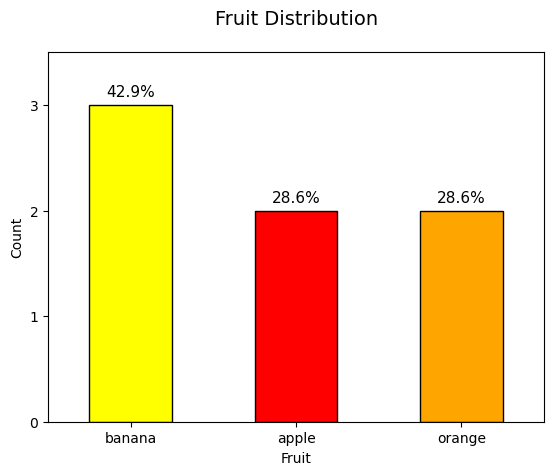

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

data = {
    "fruit": ["apple", "banana", "banana", "orange", "banana", "apple", "orange"]
}

df = pd.DataFrame(data)
counts = df["fruit"].value_counts()

color_map = {"banana": "yellow", "apple": "red", "orange": "orange"}
colors = [color_map[fruit] for fruit in counts.index]

# 1. Plot as a bar chart
ax = counts.plot(kind="bar", color=colors, edgecolor="black")

# 2. Force the Y-axis tick labels to be integers only
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 3. Add percentages above bars
total = len(df)
for container in ax.containers:
    labels = [f"{(v.get_height() / total) * 100:.1f}%" for v in container]
    ax.bar_label(container, labels=labels, label_type="edge", padding=4, fontsize=11)

# 4. Customize chart labels
plt.title("Fruit Distribution", pad=20, fontsize=14)
plt.xlabel("Fruit")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Ensure extra padding at the top so labels don't get cut off
plt.ylim(0, counts.max() + 0.5)

# 5. Display the chart
plt.show()


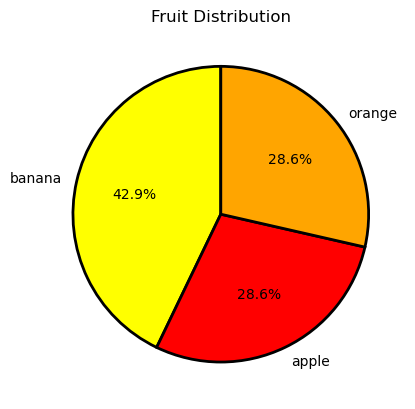

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "fruit": ["apple", "banana", "banana", "orange", "banana", "apple", "orange"]
}

df = pd.DataFrame(data)
counts = df["fruit"].value_counts()

# Map colors to match the order of counts (banana, apple, orange)
color_map = {"banana": "yellow", "apple": "red", "orange": "orange"}
colors = [color_map[fruit] for fruit in counts.index]

counts.plot.pie(
    autopct="%1.1f%%", startangle=90, ylabel="", colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}
)

plt.title("Fruit Distribution")
plt.show()


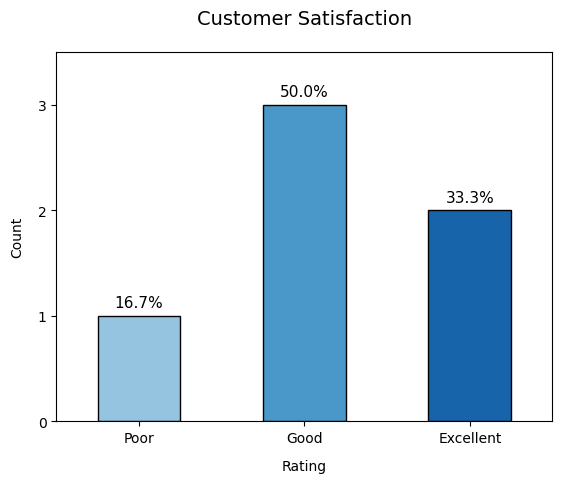

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# 1. Create sample ordinal data
data = {"satisfaction": ["Good", "Excellent", "Poor", "Good", "Excellent", "Good"]}
df = pd.DataFrame(data)

# 2. Define the logical order of your categories
ordinal_order = ["Poor", "Good", "Excellent"] 

# 3. Convert column to an ordered Categorical type
df["satisfaction"] = pd.Categorical(
    df["satisfaction"], categories=ordinal_order, ordered=True
)

# 4. Count and sort by the categorical index
counts = df["satisfaction"].value_counts().sort_index()

# 5. Generate colors from the colormap manually
cmap = plt.colormaps["Blues"]
bar_colors = cmap(np.linspace(0.4, 0.8, len(counts)))  # Adjusted minimum to 0.4 for better bar visibility

# 6. Plot as a BAR chart instead of a pie chart
ax = counts.plot(kind="bar", color=bar_colors, edgecolor="black")

# 7. Force the Y-axis tick labels to be integers only
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 8. Calculate and add percentages above the bars
total_count = len(df)
for container in ax.containers:
    labels = [f"{(bar.get_height() / total_count) * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, label_type="edge", padding=4, fontsize=11)

# 9. Customize chart labels and limits
plt.title("Customer Satisfaction", pad=20, fontsize=14)
plt.xlabel("Rating", labelpad=10)
plt.ylabel("Count", labelpad=10)
plt.xticks(rotation=0)  # Keeps category names horizontal

# Ensure extra padding at the top of the grid so text labels don't clip
plt.ylim(0, counts.max() + 0.5)

# 10. Display chart
plt.show()


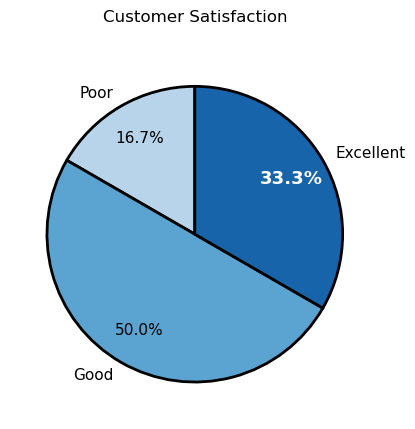

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create sample ordinal data
data = {"satisfaction": ["Good", "Excellent", "Poor", "Good", "Excellent", "Good"]}
df = pd.DataFrame(data)

# 2. Define the logical order of your categories
ordinal_order = ["Poor", "Good", "Excellent"]

# 3. Convert column to an ordered Categorical type
df["satisfaction"] = pd.Categorical(
    df["satisfaction"], categories=ordinal_order, ordered=True
)

# 4. Count and sort by the categorical index
counts = df["satisfaction"].value_counts().sort_index()

# 5. Generate colors from the colormap manually
# This maps 3 evenly spaced points along the 'Blues' gradient (e.g., 0.3 to 0.8)
cmap = plt.colormaps["Blues"]
slice_colors = cmap(np.linspace(0.3, 0.8, len(counts)))

# 6. Plot as a pie chart
wedges, texts, autotexts = plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=slice_colors,  # Pass the generated colors here
    pctdistance=0.75,
    textprops={"fontsize": 11},
    wedgeprops={'edgecolor': 'black', 'linewidth': 2},
)

# 7. Customize the "Excellent" percentage label specifically
# index 2 corresponds to the third category: "Excellent"
autotexts[2].set_color("white")
autotexts[2].set_weight("bold")
autotexts[2].set_fontsize(13)

# 8. Customize chart labels
plt.title("Customer Satisfaction", pad=20)

# 9. Display chart
plt.show()


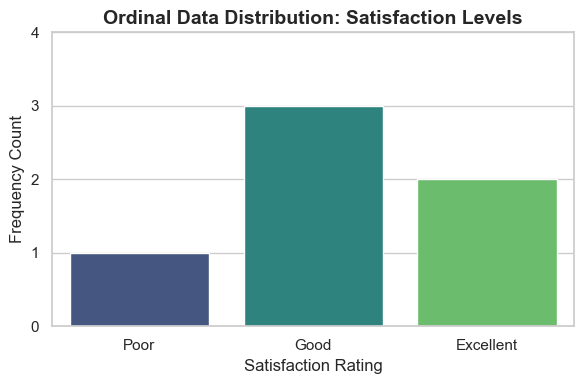

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# 1. Define the raw ordinal data
data = {"satisfaction": ["Good", "Excellent", "Poor", "Good", "Excellent", "Good"]}

# 2. Convert dictionary into a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Define the explicit logical order for your ordinal categories
category_order = ["Poor", "Good", "Excellent"]

# 4. Convert the column to a Categorical type with the specified order
df["satisfaction"] = pd.Categorical(df["satisfaction"], categories=category_order, ordered=True)

# 5. Set up the Seaborn plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# 6. Create the count plot with the strict categorical ordering
ax = sns.countplot(data=df, x="satisfaction", order=category_order, hue="satisfaction", legend=False, palette="viridis")

# Force the y-axis to use integer labels only
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# 7. Add labels and titles to the chart
plt.title("Ordinal Data Distribution: Satisfaction Levels", fontsize=14, fontweight="bold")
plt.xlabel("Satisfaction Rating", fontsize=12)
plt.ylabel("Frequency Count", fontsize=12)
plt.ylim(0, 4)  # Sets room above the tallest bar (count of 3)

# 8. Display the plot on your screen
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# 1. Define the raw data
data = {"satisfaction": ["Good", "Excellent", "Poor", "Good", "Excellent", "Good"]}
df = pd.DataFrame(data)

# 2. Set the strict ordinal sequence (Crucial for correct accumulation)
category_order = ["Poor", "Good", "Excellent"]
df["satisfaction"] = pd.Categorical(df["satisfaction"], categories=category_order, ordered=True)

# 3. Compute individual probabilities (Probability Mass Function / PMF)
# value_counts(normalize=True) converts absolute counts into proportions
pmf = df["satisfaction"].value_counts(normalize=True).reindex(category_order)

# 4. Calculate the Cumulative Probability Distribution (CPD) using cumsum()
cpd = pmf.cumsum()

# 5. Combine results into a neat summary table
cpd_table = pd.DataFrame({
    'Frequency': df["satisfaction"].value_counts().reindex(category_order),
    'Probability (PMF)': pmf,
    'Cumulative Probability (CPD)': cpd
})

print(cpd_table)


              Frequency  Probability (PMF)  Cumulative Probability (CPD)
satisfaction                                                            
Poor                  1           0.166667                      0.166667
Good                  3           0.500000                      0.666667
Excellent             2           0.333333                      1.000000


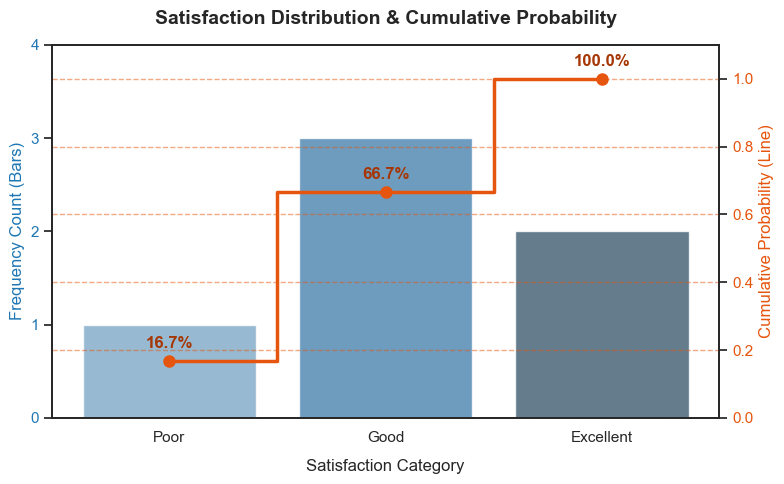

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# 1. Prepare and calculate data
data = {"satisfaction": ["Good", "Excellent", "Poor", "Good", "Excellent", "Good"]}
df = pd.DataFrame(data)

category_order = ["Poor", "Good", "Excellent"]
df["satisfaction"] = pd.Categorical(df["satisfaction"], categories=category_order, ordered=True)

# Compute metrics
counts = df["satisfaction"].value_counts().reindex(category_order)
pmf = df["satisfaction"].value_counts(normalize=True).reindex(category_order)
cpd = pmf.cumsum()

# 2. Setup the figure and the first axis (Left Y-axis for Frequencies)
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(8, 5))

# Draw the frequency bars
sns.barplot(x=counts.index, y=counts.values, ax=ax1, palette="Blues_d", hue=counts.index, legend=False, alpha=0.8)
ax1.set_title("Satisfaction Distribution & Cumulative Probability", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Satisfaction Category", fontsize=12, labelpad=10)
ax1.set_ylabel("Frequency Count (Bars)", color="#1f77b4", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#1f77b4")
ax1.set_ylim(0, 4)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
# 3. Create a twin axis sharing the same X-axis (Right Y-axis for CPD)
ax2 = ax1.twinx()

# Draw the cumulative step line
ax2.step(cpd.index, cpd.values, where='mid', color='#e6550d', linewidth=2.5, marker='o', markersize=8, label="CPD")
ax2.set_ylabel("Cumulative Probability (Line)", color="#e6550d", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#e6550d")
ax2.set_ylim(0, 1.1)
ax2.grid(True, linestyle="--", alpha=0.5, color="#e6550d") # Grid aligned to CPD

# 4. Annotate exact cumulative percentages on the line
for x, y in zip(cpd.index, cpd.values):
    ax2.text(x, y + 0.03, f"{y*100:.1f}%", ha='center', va='bottom', color='#a63603', fontweight='bold')

# 5. Export and show options
plt.tight_layout()
# plt.savefig("satisfaction_cpd_plot.png", dpi=300) # Uncomment to save file
plt.show()


In [10]:
df = pd.read_csv("winequality-red.csv")

In [11]:
qualities = df['quality']

In [12]:
print(qualities)

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64


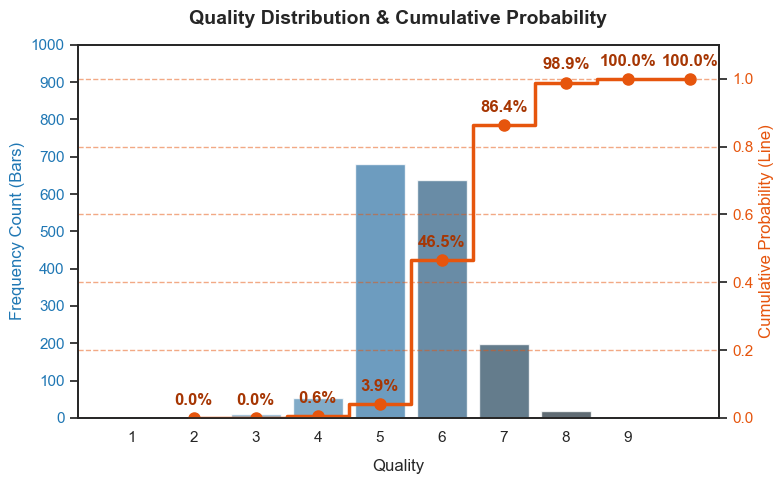

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# 1. Prepare and calculate data
data = {"quality": qualities}
df = pd.DataFrame(data)

category_order = [1, 2, 3, 4, 5, 6, 7, 8, 9]
df["quality"] = pd.Categorical(df["quality"], categories=category_order, ordered=True)

# Compute metrics
counts = df["quality"].value_counts().reindex(category_order)
pmf = df["quality"].value_counts(normalize=True).reindex(category_order)
cpd = pmf.cumsum()

# 2. Setup the figure and the first axis (Left Y-axis for Frequencies)
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(8, 5))

# Draw the frequency bars
sns.barplot(x=counts.index, y=counts.values, ax=ax1, palette="Blues_d", hue=counts.index, legend=False, alpha=0.8)
ax1.set_title("Quality Distribution & Cumulative Probability", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Quality", fontsize=12, labelpad=10)
ax1.set_ylabel("Frequency Count (Bars)", color="#1f77b4", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#1f77b4")
ax1.set_ylim(0, 1000)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
# 3. Create a twin axis sharing the same X-axis (Right Y-axis for CPD)
ax2 = ax1.twinx()

# Draw the cumulative step line
ax2.step(cpd.index, cpd.values, where='mid', color='#e6550d', linewidth=2.5, marker='o', markersize=8, label="CPD")
ax2.set_ylabel("Cumulative Probability (Line)", color="#e6550d", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#e6550d")
ax2.set_ylim(0, 1.1)
ax2.grid(True, linestyle="--", alpha=0.5, color="#e6550d") # Grid aligned to CPD

# 4. Annotate exact cumulative percentages on the line
for x, y in zip(cpd.index, cpd.values):
    ax2.text(x, y + 0.03, f"{y*100:.1f}%", ha='center', va='bottom', color='#a63603', fontweight='bold')

# 5. Export and show options
plt.tight_layout()
# plt.savefig("satisfaction_cpd_plot.png", dpi=300) # Uncomment to save file
plt.show()
